In [5]:

import numpy as np

from Kea.utils import plotting

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()


In [6]:

def SmoothySpec(a,start=None,end=None,width=3):
   b=a.copy()
   if start is None: start = 0
   if end is None: end = len(a)
   for i in range(start,end):
      b[i+1::][:-1] = 0.25*b[i::][:-2]+0.5*b[i+1::][:-1]+0.25*b[i::][2:]
      #b[i+1:-1] = 0.25*b[i:-2] + 0.5*b[i+1:-1] + 0.25*b[i+2:]
   return b


In [7]:

k = np.load('kmag.npy')
fek = np.load('fek_ii.npy')
N = len(k)


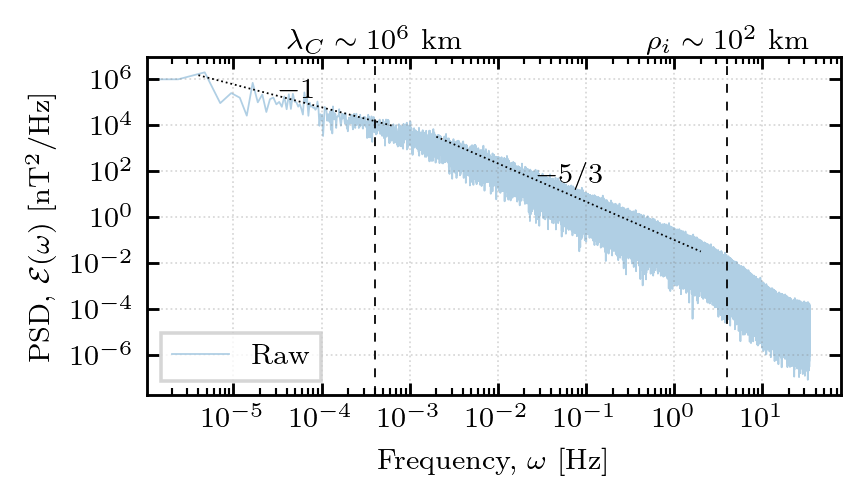

In [8]:

fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

ax.plot(k, fek, linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
# fekss = np.exp(SmoothySpec(np.log(fek)))
# for _ in range(25):
#     fekss = np.exp(SmoothySpec(np.log(fek)))
# ax.loglog(k, fekss, linewidth=1., zorder=1, label='Raw Smoothed', color='gray')

kp1 = np.exp(np.linspace(np.log(4e-6), np.log(6.5e-4), 50))
ax.plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
kp53 = np.exp(np.linspace(np.log(2e-3), np.log(2e0), 50))
ax.plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

for axx in [ax]:
    axx.set_yscale('log')
    axx.set_xscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.legend(frameon=True, fancybox=False, loc='lower left')

U = 400. #km/s
lc = 1e6 #km
ri = 1e2 #km
lt = 3225. #km
re = 1e0 #km

props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

#ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

#ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

ax.text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
ax.text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.xaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.xaxis.set_minor_locator(locmin)

ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

fig.align_ylabels()

fig.savefig('large_SW.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
#fig.savefig('large_SW.png', transparent=True, bbox_inches='tight', pad_inches=0)
